# Import

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import sklearn
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

In [2]:
load_dotenv()
PATH_PROJECT = Path(os.getenv('PATH_PROJECT'))
PATH_DATA = Path(os.getenv('PATH_DATA'))
PATH_WEIGHTS = Path(os.getenv('PATH_WEIGHTS'))

# sklearn.set_config(transform_output="pandas")
sklearn.set_config(transform_output="default")


from src.cells import RNNCell, GRUCell, LSTMCell
from src.layers import LinearLayer
from src.activations import ReLUActivation, TanhActivation
from src.structure_layers import DropoutLayer
from src.losses import MSELoss
from src.data_loaders import BaseLoader, datasets
from src.optimizers import GDOptimizer, AdamOptimizer
from src.models import RNN, GRU, LSTM
from src.tools import utils, metrics, visualizer

# Данные

## Загрузка

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = datasets.load_steel_dataset(
    PATH_DATA,
    size_test=0.15,
    size_val=0.15,
    window=10
)

## Исследование данных

In [ ]:
# Загрузка данных
df = pd.read_csv(PATH_DATA / 'Steel_industry_data.csv')

# Предобработка данных
# Переименование столбцов
df = df.rename(columns={
    'Lagging_Current_Reactive.Power_kVarh' : 'Lagging_Current_Reactive_Power_kVarh',
    'CO2(tCO2)' : 'CO2'
})

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2                                   35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

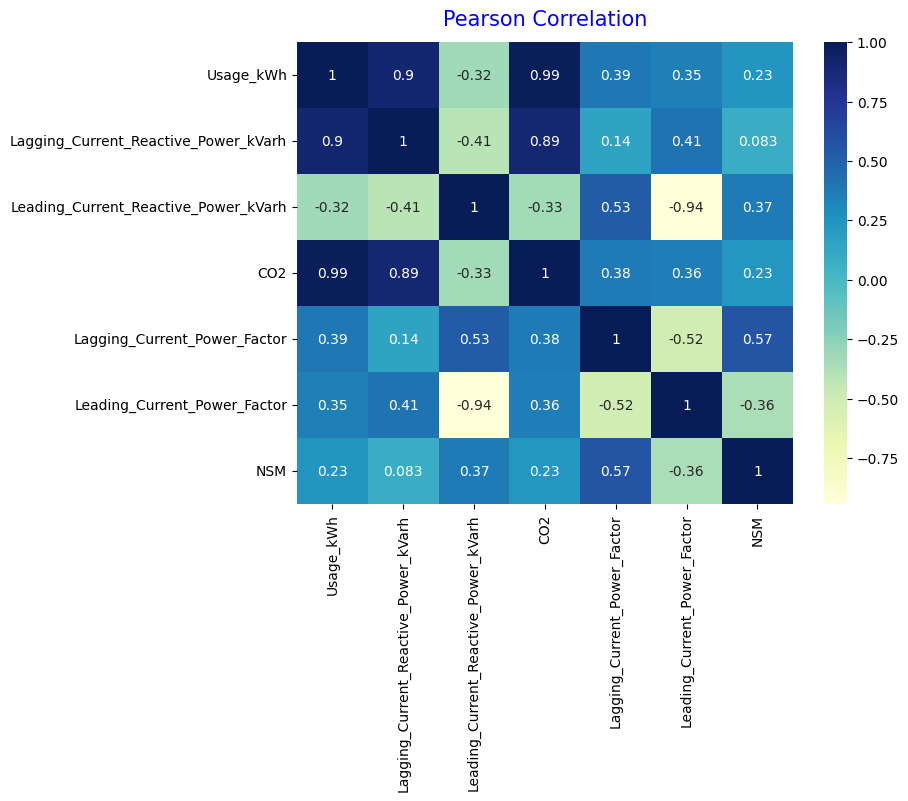

In [54]:
#visualize the correlation using pearson correlation
plt.figure(figsize = (8, 6))
sns.heatmap(df.drop(columns=['date', 'WeekStatus', 'Day_of_week', 'Load_Type']).corr(), annot=True, cmap='YlGnBu')
plt.title("Pearson Correlation", fontsize=15, color='b', pad=12, loc='center')
plt.show()

Подробный анализ данных [здесь](https://www.kaggle.com/code/bayunova/steel-industry-energy-consumption).

# RNN

## Инициализация

In [4]:
model = RNN([
    RNNCell(in_features=X_train.shape[-1], hidden_size=5, bias=True, activation=TanhActivation()),
    LinearLayer(in_features=5, out_features=1, bias=True)
])

## Обучение

In [5]:
# Инициализируем Loss и оптимизатор
loss = MSELoss()
data_loader = BaseLoader(batch_size=32)
optimizer = AdamOptimizer(
    model_weights_layers=model.get_weights_layers(),
    data_loader=data_loader,
    lr=0.01,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-7
)

def postprocess(outputs):
    return outputs.reshape(outputs.shape[0], outputs.shape[1])

In [6]:
# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 50
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=r2_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple, verbose_statistic='EMA'
)

Epoch 1 (0/24518):	Train MSELoss = 0.186	Val MSELoss = 0.186	r2_score = -15.632
Epoch 1 (1600/24518):	Train MSELoss = 0.154	Val MSELoss = 0.154	r2_score = -7.817
Epoch 1 (3200/24518):	Train MSELoss = 0.127	Val MSELoss = 0.127	r2_score = -5.109
Epoch 1 (4800/24518):	Train MSELoss = 0.106	Val MSELoss = 0.106	r2_score = -3.642
Epoch 1 (6400/24518):	Train MSELoss = 0.089	Val MSELoss = 0.089	r2_score = -2.783
Epoch 1 (8000/24518):	Train MSELoss = 0.073	Val MSELoss = 0.073	r2_score = -2.173
Epoch 1 (9600/24518):	Train MSELoss = 0.06	Val MSELoss = 0.06	r2_score = -1.736
Epoch 1 (11200/24518):	Train MSELoss = 0.05	Val MSELoss = 0.05	r2_score = -1.412
Epoch 1 (12800/24518):	Train MSELoss = 0.042	Val MSELoss = 0.042	r2_score = -1.163
Epoch 1 (14400/24518):	Train MSELoss = 0.034	Val MSELoss = 0.034	r2_score = -0.957
Epoch 1 (16000/24518):	Train MSELoss = 0.029	Val MSELoss = 0.029	r2_score = -0.788
Epoch 1 (17600/24518):	Train MSELoss = 0.024	Val MSELoss = 0.024	r2_score = -0.646
Epoch 1 (19200/24

## Оценка

Качество работы моделей по *MSE*, *RMSE* и $R^2$:

In [8]:
model.eval()
y_pred = postprocess(model(X_test))

print(f'MSE: {round(mean_squared_error(y_test, y_pred), 3)}')
print(f'RMSE: {round(root_mean_squared_error(y_test, y_pred), 3)}')
print(f'R^2: {round(r2_score(y_test, y_pred), 3)}')

MSE: 0.002
RMSE: 0.045
R^2: 0.953


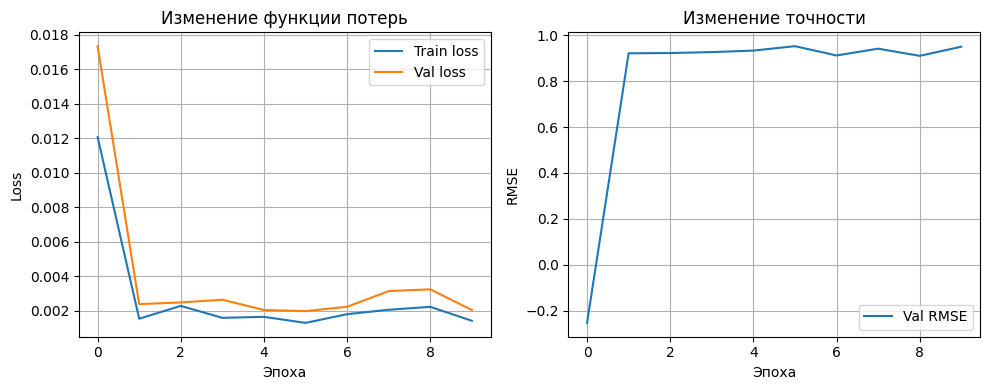

In [ ]:
visualizer.vis_losses_metrics(model, 'RMSE')

# GRU

## Инициализация

In [4]:
model = GRU([
    GRUCell(in_features=X_train.shape[-1], hidden_size=5, bias=True),
    LinearLayer(in_features=5, out_features=1, bias=True)
])

## Обучение

In [5]:
# Инициализируем Loss и оптимизатор
loss = MSELoss()
data_loader = BaseLoader(batch_size=32)
optimizer = AdamOptimizer(
    model_weights_layers=model.get_weights_layers(),
    data_loader=data_loader,
    lr=0.01,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-7
)

def postprocess(outputs):
    return outputs.reshape(outputs.shape[0], outputs.shape[1])

In [6]:
# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 50
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=r2_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple, verbose_statistic='EMA'
)

Epoch 1 (0/24518):	Train MSELoss = 0.164	Val MSELoss = 0.164	r2_score = -1.667
Epoch 1 (1600/24518):	Train MSELoss = 0.14	Val MSELoss = 0.14	r2_score = -0.714
Epoch 1 (3200/24518):	Train MSELoss = 0.117	Val MSELoss = 0.117	r2_score = -0.509
Epoch 1 (4800/24518):	Train MSELoss = 0.098	Val MSELoss = 0.098	r2_score = -0.176
Epoch 1 (6400/24518):	Train MSELoss = 0.084	Val MSELoss = 0.084	r2_score = -0.012
Epoch 1 (8000/24518):	Train MSELoss = 0.069	Val MSELoss = 0.069	r2_score = 0.142
Epoch 1 (9600/24518):	Train MSELoss = 0.057	Val MSELoss = 0.057	r2_score = 0.254
Epoch 1 (11200/24518):	Train MSELoss = 0.047	Val MSELoss = 0.047	r2_score = 0.341
Epoch 1 (12800/24518):	Train MSELoss = 0.039	Val MSELoss = 0.039	r2_score = 0.409
Epoch 1 (14400/24518):	Train MSELoss = 0.032	Val MSELoss = 0.032	r2_score = 0.458
Epoch 1 (16000/24518):	Train MSELoss = 0.028	Val MSELoss = 0.028	r2_score = 0.483
Epoch 1 (17600/24518):	Train MSELoss = 0.025	Val MSELoss = 0.025	r2_score = 0.518
Epoch 1 (19200/24518):	

## Оценка

Качество работы моделей по *MSE*, *RMSE* и $R^2$:

In [7]:
model.eval()
y_pred = postprocess(model(X_test))

print(f'MSE: {round(mean_squared_error(y_test, y_pred), 3)}')
print(f'RMSE: {round(root_mean_squared_error(y_test, y_pred), 3)}')
print(f'R^2: {round(r2_score(y_test, y_pred), 3)}')

MSE: 0.001
RMSE: 0.03
R^2: 0.979


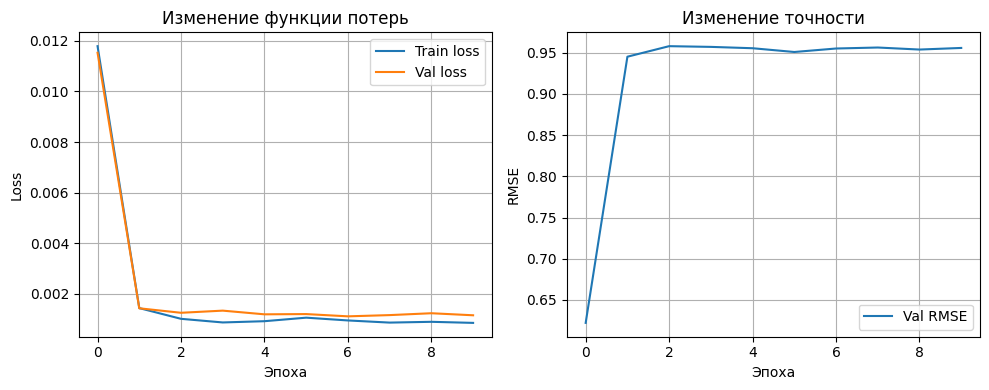

In [8]:
visualizer.vis_losses_metrics(model, 'RMSE')

# LSTM

## Инициализация

In [4]:
model = LSTM([
    LSTMCell(in_features=X_train.shape[-1], hidden_size=5, bias=True),
    LinearLayer(in_features=5, out_features=1, bias=True)
])

## Обучение

In [5]:
# Инициализируем Loss и оптимизатор
loss = MSELoss()
data_loader = BaseLoader(batch_size=32)
optimizer = AdamOptimizer(
    model_weights_layers=model.get_weights_layers(),
    data_loader=data_loader,
    lr=0.01,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-7
)

def postprocess(outputs):
    return outputs.reshape(outputs.shape[0], outputs.shape[1])

In [6]:
# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 50
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=r2_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple, verbose_statistic='EMA'
)

Epoch 1 (0/24518):	Train MSELoss = 0.03	Val MSELoss = 0.03	r2_score = -0.387
Epoch 1 (1600/24518):	Train MSELoss = 0.03	Val MSELoss = 0.03	r2_score = -0.141
Epoch 1 (3200/24518):	Train MSELoss = 0.025	Val MSELoss = 0.025	r2_score = 0.025
Epoch 1 (4800/24518):	Train MSELoss = 0.022	Val MSELoss = 0.022	r2_score = 0.197
Epoch 1 (6400/24518):	Train MSELoss = 0.02	Val MSELoss = 0.02	r2_score = 0.284
Epoch 1 (8000/24518):	Train MSELoss = 0.018	Val MSELoss = 0.018	r2_score = 0.384
Epoch 1 (9600/24518):	Train MSELoss = 0.015	Val MSELoss = 0.015	r2_score = 0.46
Epoch 1 (11200/24518):	Train MSELoss = 0.014	Val MSELoss = 0.014	r2_score = 0.516
Epoch 1 (12800/24518):	Train MSELoss = 0.012	Val MSELoss = 0.012	r2_score = 0.558
Epoch 1 (14400/24518):	Train MSELoss = 0.01	Val MSELoss = 0.01	r2_score = 0.596
Epoch 1 (16000/24518):	Train MSELoss = 0.008	Val MSELoss = 0.008	r2_score = 0.627
Epoch 1 (17600/24518):	Train MSELoss = 0.007	Val MSELoss = 0.007	r2_score = 0.655
Epoch 1 (19200/24518):	Train MSEL

## Оценка

Качество работы моделей по *MSE*, *RMSE* и $R^2$:

In [7]:
model.eval()
y_pred = postprocess(model(X_test))

print(f'MSE: {round(mean_squared_error(y_test, y_pred), 3)}')
print(f'RMSE: {round(root_mean_squared_error(y_test, y_pred), 3)}')
print(f'R^2: {round(r2_score(y_test, y_pred), 3)}')

MSE: 0.001
RMSE: 0.025
R^2: 0.985


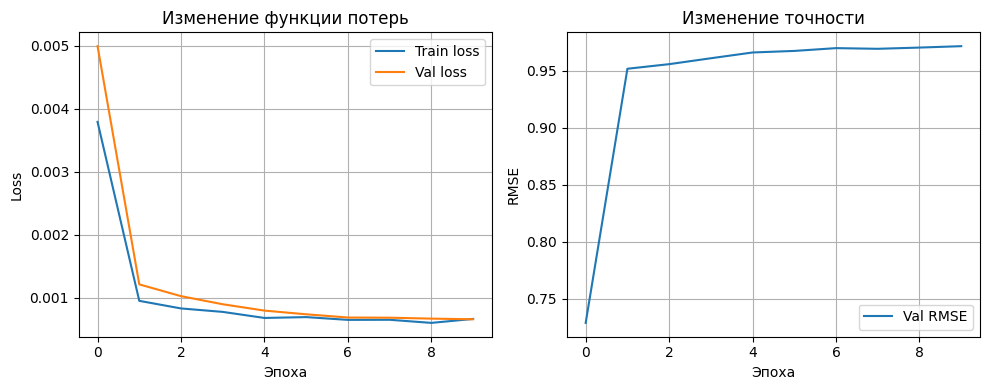

In [8]:
visualizer.vis_losses_metrics(model, 'RMSE')

# Выводы

Сводная таблица качества:

| М/О    | *MSE* | *RMSE*| $R^2$ |
|--------|-------|-------|-------|
| *RNN*  | 0.002 | 0.045 | 0.953 |
| *GRU*  | 0.001 | 0.03  | 0.979 |
| *LSTM* | 0.001 | 0.025 | 0.985 |

# Temp

## Forward pass

In [17]:
# Тестовые данные
test_X = X_train[:1]
# Параметры
_, _, n_features = test_X.shape
n_outputs = 1
hidden_size = 10  # размер скрытого состояния

# Инициализация моей ячейки RNN
custom_rnn = RNNCell(in_features=n_features, hidden_size=hidden_size, bias=True, activation=TanhActivation())
# Инициализация PyTorch ячейки RNN
pytorch_model = nn.RNN(n_features, hidden_size, batch_first=True)

# Передача весов из моей ячейки в PyTorch ячейку
with torch.no_grad():
    pytorch_model.weight_ih_l0.copy_(torch.from_numpy(custom_rnn.W))
    pytorch_model.weight_hh_l0.copy_(torch.from_numpy(custom_rnn.Wh))
    pytorch_model.bias_ih_l0.copy_(torch.from_numpy(custom_rnn.b))
    pytorch_model.bias_hh_l0.copy_(torch.from_numpy(custom_rnn.bh))

# Инициализация скрытого состояния
h0_custom = np.zeros((1, hidden_size), dtype=np.float32)
h0_torch = torch.zeros(1, 1, hidden_size)
# h0_custom = None
# h0_torch = None

In [18]:
# Прогон данных
custom_outputs, custom_h = custom_rnn(test_X, h0_custom)
pytorch_outputs, pytorch_h = pytorch_model(torch.from_numpy(test_X).float(), h0_torch)
pytorch_outputs, pytorch_h = pytorch_outputs.detach().numpy(), pytorch_h.detach().numpy()
# Вывод
print("outputs error:", np.abs(pytorch_outputs - custom_outputs).max())
print("h error:", np.abs(pytorch_h - custom_h).max())

outputs error: 1.133137376568838e-07
h error: 6.176948230685042e-08


## Backward pass

In [ ]:
# Тестовые данные
test_X = X_train[:1].astype(np.float32)
torch_X = torch.from_numpy(test_X).float().requires_grad_(True)
# Параметры
_, _, n_features = test_X.shape
n_outputs = 1
hidden_size = 10  # размер скрытого состояния

# Инициализация моей ячейки RNN
custom_rnn = RNNCell(in_features=n_features, hidden_size=hidden_size, bias=True, activation=TanhActivation())
# Инициализация PyTorch ячейки RNN
pytorch_model = nn.RNN(n_features, hidden_size, batch_first=True)

# Передача весов из моей ячейки в PyTorch ячейку
with torch.no_grad():
    pytorch_model.weight_ih_l0.copy_(torch.from_numpy(custom_rnn.W))
    pytorch_model.weight_hh_l0.copy_(torch.from_numpy(custom_rnn.Wh))
    pytorch_model.bias_ih_l0.copy_(torch.from_numpy(custom_rnn.b))
    pytorch_model.bias_hh_l0.copy_(torch.from_numpy(custom_rnn.bh))

# Инициализация скрытого состояния
h0_custom = np.zeros((1, hidden_size), dtype=np.float32)
h0_torch = torch.zeros(1, 1, hidden_size)
# h0_custom = None
# h0_torch = None

In [ ]:
# Forward pass
custom_outputs, _ = custom_rnn(test_X, h0_custom)
pytorch_outputs, _ = pytorch_model(torch_X, h0_torch)

# Случайный градиент по выходу для проверки backward
grad_output = np.random.randn(*custom_outputs.shape).astype(np.float32)
delta = grad_output

# backward_pass в моей ячейке
grad_input_custom = custom_rnn.backward_pass(delta)

# backward в PyTorch
pytorch_outputs.backward(torch.from_numpy(grad_output))
grad_input_torch = torch_X.grad.numpy()

# Проверка градиентов
print("Max error in grad_input:", np.abs(grad_input_custom - grad_input_torch).max())
print("Max error in grad W:", np.abs(custom_rnn.gradW - pytorch_model.weight_ih_l0.grad.numpy()).max())
print("Max error in grad Wh:", np.abs(custom_rnn.gradWh - pytorch_model.weight_hh_l0.grad.numpy()).max())
print("Max error in grad b:", np.abs(custom_rnn.gradb - pytorch_model.bias_ih_l0.grad.numpy()).max())
print("Max error in grad bh:", np.abs(custom_rnn.gradbh - pytorch_model.bias_hh_l0.grad.numpy()).max())

Max error in grad_input: 5.9604645e-07
Max error in grad W: 1.9073486e-06
Max error in grad Wh: 2.3841858e-06
Max error in grad b: 2.3841858e-06
Max error in grad bh: 3.33786e-06


## Model

In [4]:
class PytorchRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, bias):
        super(PytorchRNNModel, self).__init__()
        
        # RNN слой
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bias=bias
        )
        
        # Linear слой
        self.fc = nn.Linear(hidden_size, output_size, bias=bias)
        
    def forward(self, x):
        # RNN возвращает: output и hidden state
        rnn_out, _ = self.rnn(x)  # rnn_out: (batch, seq_len, hidden)
        
        # Применяем Linear слой
        # Если хотим output на каждый шаг: оставляем rnn_out как есть
        out = self.fc(rnn_out)  # (batch, seq_len, output_size)
        
        # Если нужен только последний шаг:
        # out = self.fc(rnn_out[:, -1, :])  # (batch, output_size)
        
        return out


def postprocess(outputs):
    return outputs.reshape(outputs.shape[0], outputs.shape[1])


# Инструменты
loss = MSELoss()
data_loader = BaseLoader(batch_size=3)

# Тестовые данные
_, test_X, test_y = next(iter(data_loader.get_data(X_test, y_test)))
torch_X = torch.from_numpy(test_X).float().requires_grad_(True)
# Параметры
_, _, n_features = test_X.shape
n_outputs = 1
hidden_size = 10  # размер скрытого состояния
bias = True

# Инициализация моей модели
custom_model = RNN([
    RNNCell(in_features=n_features, hidden_size=hidden_size, bias=True, activation=TanhActivation()),
    LinearLayer(in_features=hidden_size, out_features=n_outputs, bias=bias)
])
# Инициализация PyTorch ячейки RNN
pytorch_model = PytorchRNNModel(input_size=n_features, hidden_size=hidden_size, output_size=n_outputs, bias=bias)

# Передача весов из моей модели в PyTorch модель
with torch.no_grad():
    # RNN слой
    W, b, Wh, bh = custom_model.arch_model[0].get_weights()
    pytorch_model.rnn.weight_ih_l0.copy_(torch.from_numpy(W))
    pytorch_model.rnn.weight_hh_l0.copy_(torch.from_numpy(Wh))
    if b is not None:
        pytorch_model.rnn.bias_ih_l0.copy_(torch.from_numpy(b))
        pytorch_model.rnn.bias_hh_l0.copy_(torch.from_numpy(bh))
    # Linear слой
    W, b = custom_model.arch_model[1].get_weights()
    pytorch_model.fc.weight.copy_(torch.from_numpy(W))
    if b is not None:
        pytorch_model.fc.bias.copy_(torch.from_numpy(b))

In [5]:
# Forward pass
custom_outputs = custom_model(test_X)
pytorch_outputs = pytorch_model(torch_X)

loss_batch = loss(test_y, custom_outputs)

# backward_pass в моей ячейке
custom_grad = loss.backward_pass(custom_model.arch_model[-1].outputs)
for layer in reversed(custom_model.arch_model):
    # Считаем дельта правило или градиент весов и передаём ошибку дальше влево
    custom_grad = layer.backward_pass(custom_grad)

# ===== PyTorch backward =====
pytorch_model.zero_grad()
if torch_X.grad is not None:
    torch_X.grad.zero_()
# Точный аналог кастомного MSE
y_torch = torch.from_numpy(test_y).float()
if y_torch.ndim == 2:        # many-to-many
    y_torch = y_torch.unsqueeze(-1)  # (batch, seq_len, 1)
pytorch_loss = torch.mean((pytorch_outputs - y_torch) ** 2)
# Backward
pytorch_loss.backward()
# Градиент по входам
pytorch_grad = torch_X.grad.detach().numpy()


# Проверка прогона
print("Max error in outputs:", np.abs(custom_outputs - pytorch_outputs.detach().numpy()).max())
# Проверка градиентов
print("Max error in grads:", np.abs(custom_grad - pytorch_grad).max())
print("Max error in RNN grad W:", np.abs(custom_model.arch_model[0].gradW - pytorch_model.rnn.weight_ih_l0.grad.numpy()).max())
print("Max error in RNN grad Wh:", np.abs(custom_model.arch_model[0].gradWh - pytorch_model.rnn.weight_hh_l0.grad.numpy()).max())
if bias: print("Max error in RNN grad b:", np.abs(custom_model.arch_model[0].gradb - pytorch_model.rnn.bias_ih_l0.grad.numpy()).max())
if bias: print("Max error in RNN grad bh:", np.abs(custom_model.arch_model[0].gradbh - pytorch_model.rnn.bias_hh_l0.grad.numpy()).max())
print("Max error in LinearLayer grad W:", np.abs(custom_model.arch_model[1].gradW - pytorch_model.fc.weight.grad.numpy()).max())
if bias: print("Max error in LinearLayer grad b:", np.abs(custom_model.arch_model[1].gradb - pytorch_model.fc.bias.grad.numpy()).max())

Max error in outputs: 1.021557434199849e-07
Max error in grads: 5.5879354e-09
Max error in RNN grad W: 1.1920929e-07
Max error in RNN grad Wh: 5.9604645e-08
Max error in RNN grad b: 5.9604645e-08
Max error in RNN grad bh: 5.9604645e-08
Max error in LinearLayer grad W: 2.2504018448721297e-07
Max error in LinearLayer grad b: 1.8639729182368114e-07
